In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import kagglehub

In [7]:
def dataset(handle: str) -> None:
    try:
        dataset_dir = kagglehub.dataset_download(handle) 
        print(f'Dataset {handle} downloaded to {dataset_dir}')
    except ValueError:
        dataset_dir = kagglehub.competition_download(handle)
        print(f'Dataset {handle} downloaded to {dataset_dir}')
    except Exception as e:
        print(f'Error downloading dataset: {e}')
    return dataset_dir

def load_train_df(comp):
    return pd.read_csv(comp + '/train.csv')

def load_test_df(comp):
    return pd.read_csv(comp + '/test.csv')

In [13]:
train_df = load_train_df(dataset('spaceship-titanic'))
train_df

Dataset spaceship-titanic downloaded to /Users/michellezhou/.cache/kagglehub/competitions/spaceship-titanic


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


In [14]:
train_df.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='str')

In [45]:
TARGET = 'Transported'
FEATURES = [col for col in train_df.columns if col!=TARGET]

In [46]:
text_features = ['Cabin', 'Name']
categorical_features = [col for col in FEATURES if train_df[col].nunique()<25 and col not in text_features]
continuous_features = [col for col in FEATURES if train_df[col].nunique()>=25 and col not in text_features]

print(text_features)
print(categorical_features)
print(continuous_features)

['Cabin', 'Name']
['HomePlanet', 'CryoSleep', 'Destination', 'VIP']
['PassengerId', 'Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']


Text(0, 0.5, 'Number Transported')

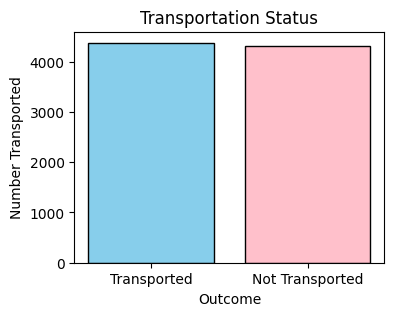

In [237]:
sizes = train_df['Transported'].value_counts()
labels = ['Transported', 'Not Transported']
plt.figure(figsize=(4,3))
bars = plt.bar(
    labels, 
    sizes, 
    color=['skyblue', 'pink'], 
    edgecolor='black'
    )
plt.title('Transportation Status')
plt.xlabel('Outcome')
plt.ylabel('Number Transported')

Basically half of the passengers were transported, and half of the passengers were not. Thus, in our EDA, we seek to find any deviations from this proportion regarding transportation and a feature. This would allude that such feature could be influencing whether a passenger was transported or not.

In [16]:
#Analyze Age Distributions First

Text(0.5, 1.0, 'Age')

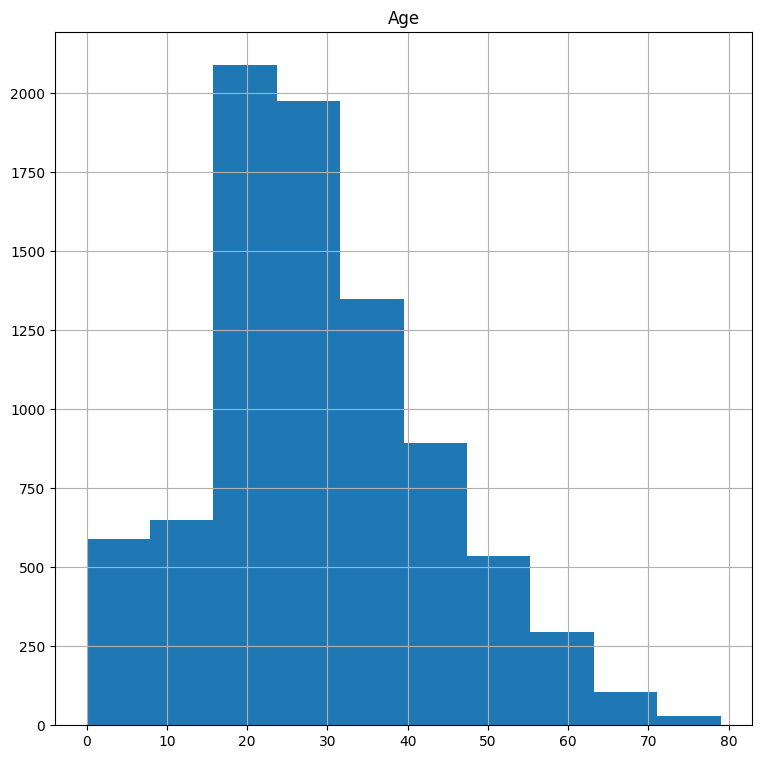

In [55]:
train_df.Age.hist(bins=10, figsize=(9,9))
plt.title('Age')

In [59]:
print('Average age on ship:', int(train_df.Age.mean()))
print('Median age on ship:', int(train_df.Age.median()))
print('Mode of ages on ship:', train_df.Age.mode(),'\n')
print('Number of passengers that are 24:', (train_df.Age==24).count())

print('Similar mean and median shows Age is approx normal with minimal skew. (Slightly skewed right)')


Average age on ship: 28
Median age on ship: 27
Mode of ages on ship: 0    24.0
Name: Age, dtype: float64 

Number of passengers that are 24: 8693
Similar mean and median shows Age is approx normal with minimal skew. (Slightly skewed right)


In [ ]:
#Break into ages that were transported and ages not transported

In [82]:
transported = train_df['Transported']==True #create a mask


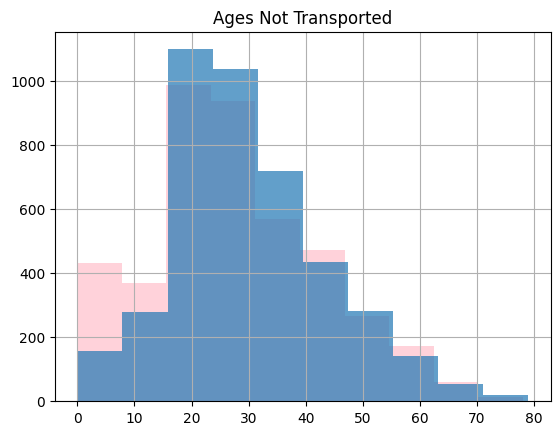

More babies - teenages were transported, and less adults were  


In [97]:
train_df.loc[transported, 'Age'].hist(alpha=0.7, color='pink')
plt.title('Ages of Transported')

train_df.loc[~transported, 'Age'].hist(alpha=0.7)
plt.title('Ages Not Transported')
plt.show()

print('More babies - teenages were transported, and less adults were transported')


Text(0, 0.5, 'Number of Passengers')

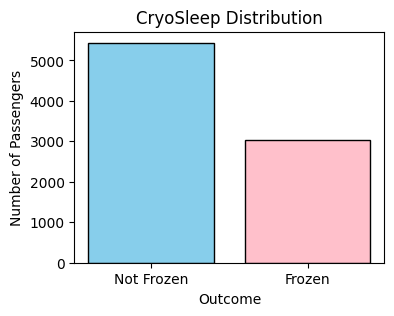

In [234]:
sizes = train_df['CryoSleep'].value_counts()
labels = ['Not Frozen', 'Frozen']
plt.figure(figsize=(4,3))
bars = plt.bar(
    labels, 
    sizes, 
    color=['skyblue', 'pink'], 
    edgecolor='black'
    )
plt.title('CryoSleep Distribution')
plt.xlabel('Outcome')
plt.ylabel('Number of Passengers')

Text(0.5, 1.0, 'CryoSleep Distribution of Transported Passengers')

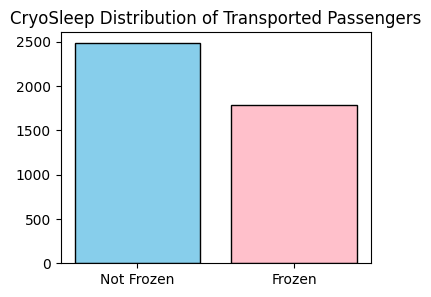

In [233]:
sizes = train_df.loc[transported,'CryoSleep'].value_counts()
labels = ['Not Frozen', 'Frozen']
plt.figure(figsize=(4,3))
bars = plt.bar(
    labels, 
    sizes, 
    color=['skyblue', 'pink'], 
    edgecolor='black'
    )
plt.title('CryoSleep Distribution of Transported Passengers')

Text(0.5, 1.0, 'CryoSleep Distribution of Not Transported Passengers')

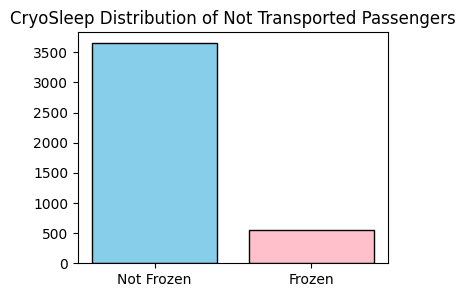

In [232]:
sizes = train_df.loc[~transported,'CryoSleep'].value_counts()
labels = ['Not Frozen', 'Frozen']
plt.figure(figsize=(4,3))
bars = plt.bar(
    labels, 
    sizes, 
    color=['skyblue', 'pink'], 
    edgecolor='black'
    )
plt.title('CryoSleep Distribution of Not Transported Passengers')

I can conclude that CryoSleep probably had some correlation of whether someone was transported or not. 
Overall, the trend is that more people were not frozen than frozen. But, the gap between the two is larger for those not transported, and smaller for those transported.
I assume this means that cabins were probably targetted. If cabins were targetted, those that were not frozen would not be transported, and those that are frozen would be transported. 

Maybe there is a correlation between young people (0-20) and cabins/CryoSleep?.

Text(0.5, 1.0, 'CryoSleep Distribution of Passengers < 20')

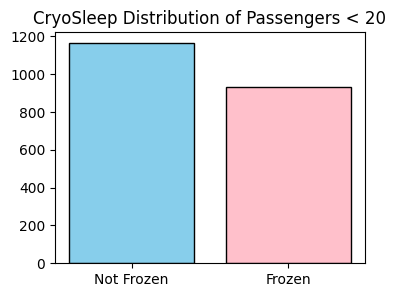

In [235]:
#Are babies or adults (20-40) more likely to be put into CryoSleep?
sizes = train_df.loc[train_df['Age']<20,'CryoSleep'].value_counts()
labels = ['Not Frozen', 'Frozen']
plt.figure(figsize=(4,3))
bars = plt.bar(
    labels, 
    sizes, 
    color=['skyblue', 'pink'], 
    edgecolor='black'
    )
plt.title('CryoSleep Distribution of Passengers < 20')

Text(0.5, 1.0, 'CryoSleep Distribution of Passengers >= 20')

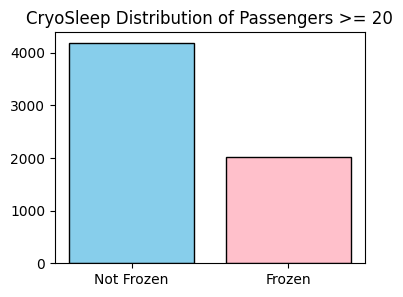

In [236]:
sizes = train_df.loc[train_df['Age']>=20,'CryoSleep'].value_counts()
labels = ['Not Frozen', 'Frozen']
plt.figure(figsize=(4,3))
bars = plt.bar(
    labels, 
    sizes, 
    color=['skyblue', 'pink'], 
    edgecolor='black'
    )
plt.title('CryoSleep Distribution of Passengers >= 20')

More younger people were in cryosleep than older people (proportionally). But more younger people were transported than older people, and those not frozen are more likely to be not transported. This means that cryoSleep may play a role in transporation/not, which could explain why more younger people were transported.
Conclude: 
- Age is probably a feature that affects Transportation
- CryoSleep might also a feature that affects Transportation, but not entirely confident

Text(0, 0.5, 'Number of Passengers')

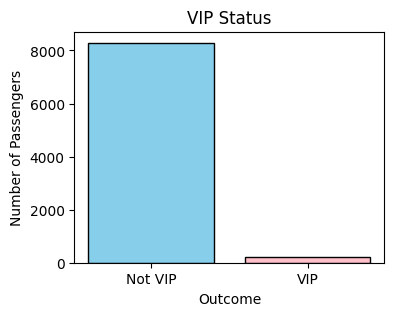

In [228]:
#VIP Distribution/Analysis
sizes = train_df['VIP'].value_counts()
labels = ['Not VIP', 'VIP']
plt.figure(figsize=(4,3))
bars = plt.bar(
    labels, 
    sizes, 
    color=['skyblue', 'pink'], 
    edgecolor='black'
    )
plt.title('VIP Status')
plt.xlabel('Outcome')
plt.ylabel('Number of Passengers')

Text(0, 0.5, 'Number of Passengers')

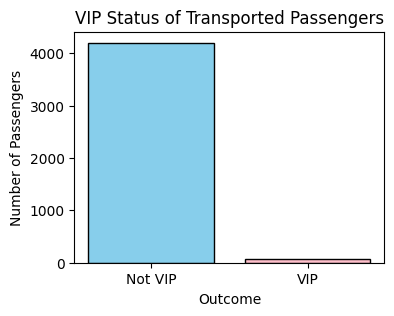

In [229]:
sizes = train_df.loc[transported, 'VIP'].value_counts()
labels = ['Not VIP', 'VIP']
plt.figure(figsize=(4,3))
bars = plt.bar(
    labels, 
    sizes, 
    color=['skyblue', 'pink'], 
    edgecolor='black'
    )
plt.title('VIP Status of Transported Passengers')
plt.xlabel('Outcome')
plt.ylabel('Number of Passengers')

Text(0, 0.5, 'Number of Passengers')

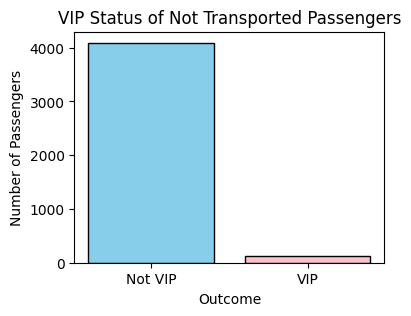

In [230]:
sizes = train_df.loc[~transported, 'VIP'].value_counts()
labels = ['Not VIP', 'VIP']
plt.figure(figsize=(4,3))
bars = plt.bar(
    labels, 
    sizes, 
    color=['skyblue', 'pink'], 
    edgecolor='black'
    )
plt.title('VIP Status of Not Transported Passengers')
plt.xlabel('Outcome')
plt.ylabel('Number of Passengers')

Since distributions are same, VIP did not seem to have an affect on transportation. The question still remains how cryosleep meant fewer transportations

In [ ]:
train_df['Cabin Deck'] = train_df['Cabin'].str[0]


Text(0, 0.5, 'Number of Passengers')

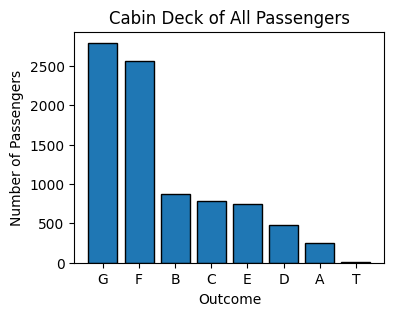

In [175]:
sizes = train_df['Cabin Deck'].value_counts()
labels = ['G', 'F', 'B', 'C', 'E', 'D', 'A', 'T']
plt.figure(figsize=(4,3))
bars = plt.bar(
    labels, 
    sizes, 
    edgecolor='black'
    )
plt.title('Cabin Deck of All Passengers')
plt.xlabel('Outcome')
plt.ylabel('Number of Passengers')

Text(0, 0.5, 'Number of Passengers')

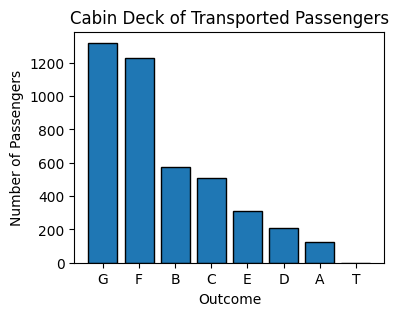

In [161]:
sizes = train_df.loc[transported, 'Cabin Deck'].value_counts()
labels = ['G', 'F', 'B', 'C', 'E', 'D', 'A', 'T']
plt.figure(figsize=(4,3))
bars = plt.bar(
    labels, 
    sizes, 
    edgecolor='black'
    )
plt.title('Cabin Deck of Transported Passengers')
plt.xlabel('Outcome')
plt.ylabel('Number of Passengers')

Text(0, 0.5, 'Number of Passengers')

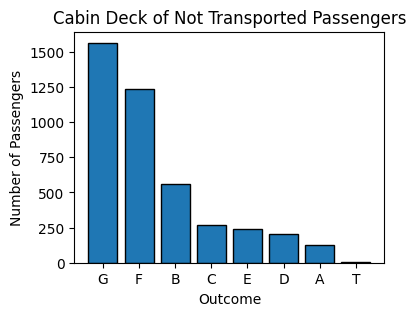

In [164]:
sizes = train_df.loc[~transported, 'Cabin Deck'].value_counts()
labels = ['G', 'F', 'B', 'C', 'E', 'D', 'A', 'T']
plt.figure(figsize=(4,3))
bars = plt.bar(
    labels, 
    sizes, 
    edgecolor='black'
    )
plt.title('Cabin Deck of Not Transported Passengers')
plt.xlabel('Outcome')
plt.ylabel('Number of Passengers')

Looking at the y -axis, the number of Not transported passengers was greater for Deck G (>1500 vs ~1300). Maybe less people were in cryosleep in cabin G?

In [174]:
print('Cabin G in cryoSleep:', ((train_df['Cabin Deck']=='G') & (train_df['CryoSleep']==True)).sum())
print('Cabin G not in cryoSleep:', ((train_df['Cabin Deck']=='G') & (train_df['CryoSleep']==False)).sum())

print('\nTransportation avoided cabin G? \nCabin is a good feature to include')


Cabin G in cryoSleep: 1350
Cabin G not in cryoSleep: 1146

Transportation avoided cabin G? 
Cabin is a good feature to include


In [177]:
train_df['Cabin Side'] = train_df['Cabin'].str[-1]

Text(0, 0.5, 'Number of Passengers')

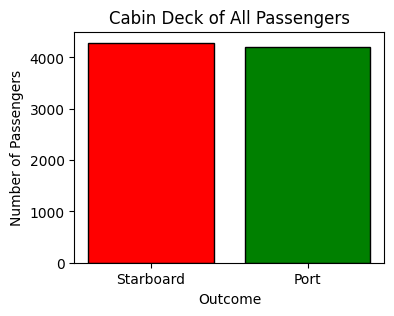

In [182]:
sizes = train_df['Cabin Side'].value_counts()
labels = ['Starboard', 'Port']
plt.figure(figsize=(4,3))
bars = plt.bar(
    labels, 
    sizes, 
    color = ['red', 'green'],
    edgecolor='black'
    )
plt.title('Cabin Side of All Passengers')
plt.xlabel('Outcome')
plt.ylabel('Number of Passengers')

Text(0, 0.5, 'Number of Passengers')

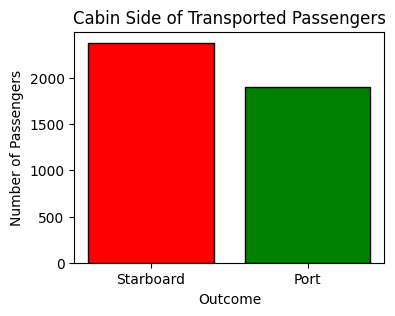

In [183]:
sizes = train_df.loc[transported, 'Cabin Side'].value_counts()
labels = ['Starboard', 'Port']
plt.figure(figsize=(4,3))
bars = plt.bar(
    labels, 
    sizes, 
    color = ['red', 'green'],
    edgecolor='black'
    )
plt.title('Cabin Side of Transported Passengers')
plt.xlabel('Outcome')
plt.ylabel('Number of Passengers')

Text(0, 0.5, 'Number of Passengers')

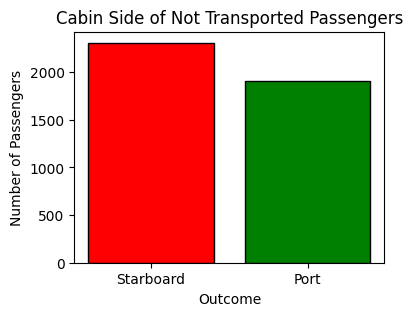

In [208]:
sizes = train_df.loc[~transported, 'Cabin Side'].value_counts()
labels = ['Starboard', 'Port']
plt.figure(figsize=(4,3))
bars = plt.bar(
    labels, 
    sizes, 
    color = ['red', 'green'],
    edgecolor='black'
    )
plt.title('Cabin Side of Not Transported Passengers')
plt.xlabel('Outcome')
plt.ylabel('Number of Passengers')

I don't believe cabin side played a role, but the cabin deck might have. 
Keep Cabin column as a feature.

In [196]:
#Passenger ID Group
train_df['PassengerGroup'] = train_df.PassengerId.str.split('_').str[0]
#ID Number
train_df['PassengerNumber'] = train_df.PassengerId.str.split('_').str[1]

In [209]:
group_size = train_df.groupby('PassengerGroup').size()
large_group = group_size[group_size>1].index


In [216]:
group_transport_rate=train_df.groupby('PassengerGroup')['Transported'].mean()
print('Passenger group transport rate:', group_transport_rate)
print('\n')
print('Passenger group not transported rate:', 1-group_transport_rate)



Passenger group transport rate: PassengerGroup
0001    0.000000
0002    1.000000
0003    0.000000
0004    1.000000
0005    1.000000
          ...   
9275    0.666667
9276    0.000000
9278    0.000000
9279    1.000000
9280    0.500000
Name: Transported, Length: 6217, dtype: float64


Passenger group not transported rate: PassengerGroup
0001    1.000000
0002    0.000000
0003    1.000000
0004    0.000000
0005    0.000000
          ...   
9275    0.333333
9276    1.000000
9278    1.000000
9279    0.000000
9280    0.500000
Name: Transported, Length: 6217, dtype: float64

 PassengerGroup
0003    0.000000
0006    1.000000
0008    1.000000
0017    0.500000
0020    0.166667
          ...   
9252    1.000000
9267    1.000000
9272    0.500000
9275    0.666667
9280    0.500000
Name: Transported, Length: 1412, dtype: float64


In [224]:
large_group_transport_rate = (train_df[train_df['PassengerGroup'].isin(large_group)]
                                       .groupby('PassengerGroup')['Transported'].mean())

print('\n', large_group_transport_rate)
print('\nNumber of groups larger than 1 not transported:', (large_group_transport_rate==0).sum())


 PassengerGroup
0003    0.000000
0006    1.000000
0008    1.000000
0017    0.500000
0020    0.166667
          ...   
9252    1.000000
9267    1.000000
9272    0.500000
9275    0.666667
9280    0.500000
Name: Transported, Length: 1412, dtype: float64

Number of groups larger than 1 not transported: 237


Passenger Id had some influence, because if one person in a group>1 was transported, most likely the rest or more than half were transported too. 
Only 237 groups had no transports at all.

Text(0.5, 1.0, 'Destination for All Passengers')

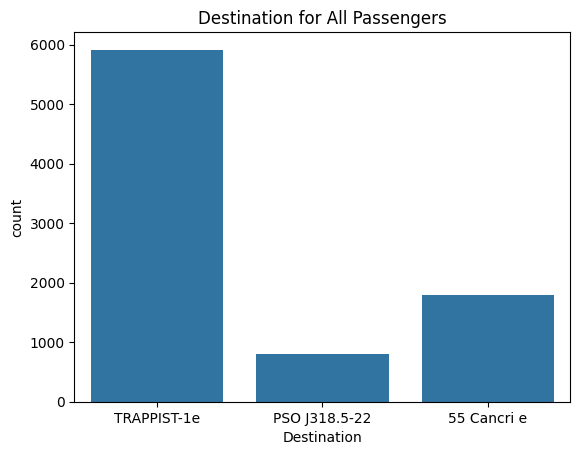

In [262]:
sns.countplot(
    data = train_df,
    x='Destination'
)
plt.title("Destination for All Passengers")

Text(0.5, 1.0, 'Destination vs Transport Status')

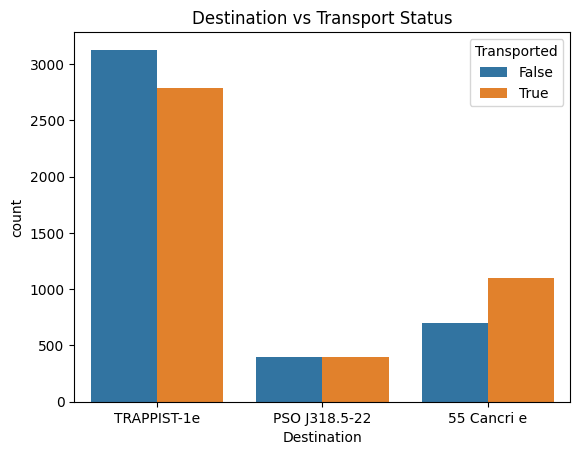

In [269]:
#Destination
sns.countplot(
    data = train_df,
    x = 'Destination',
    hue = 'Transported',
)
plt.title("Destination vs Transport Status")

- It seems like PSO J318.5-22 were transported at equal rates, meaning that either Transport randomly chose within this group, or Transport affected a certain area with an even distribution of PSO J318 arrivers. It is difficult to tell which one is the case.
- Transport didn't affect more gorups than others, because overall bar heights follow the general trend. 
- 55 Cancri e were more likely to be transported than not. 
- TRAPPIST-1e were less likely to be transported.
- Transport could target 55 Cancri e, not affect PSO, and avoid TRAPPIST.

Destination is a feature to add.

Text(0.5, 1.0, 'Home Planet for All Passengers')

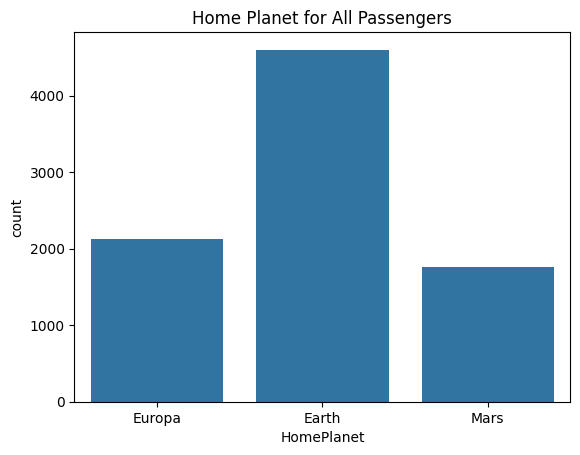

In [265]:
sns.countplot(
    data = train_df,
    x='HomePlanet'
)
plt.title("Home Planet for All Passengers")

Text(0.5, 1.0, 'Home Planet vs Transport Status')

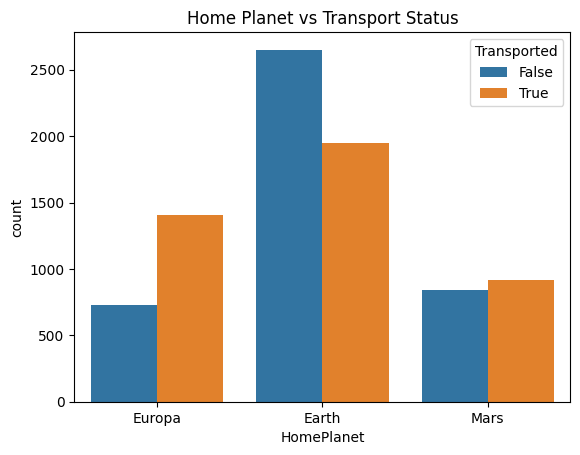

In [270]:
sns.countplot(
    data = train_df,
    x = 'HomePlanet',
    hue = 'Transported',
)
plt.title("Home Planet vs Transport Status")

- Passengers from Europa had more transports than not
- Passengers from Earth had fewer transports
- Transport could have taken more from Europe and less from Earth; not entirely random
- Above, we found that those to 55 Cancri had higher Transport Rates
- Those to TRAPPIST had lower transport rates

Let's check to see if there is a correlation between from Europe to Cancri and from Earth to TRAPPIST:

In [272]:
train_df.groupby(['HomePlanet', 'Destination'])['Transported'].mean()

HomePlanet  Destination  
Earth       55 Cancri e      0.504348
            PSO J318.5-22    0.498596
            TRAPPIST-1e      0.389229
Europa      55 Cancri e      0.689616
            PSO J318.5-22    0.736842
            TRAPPIST-1e      0.634987
Mars        55 Cancri e      0.611399
            PSO J318.5-22    0.448980
            TRAPPIST-1e      0.511864
Name: Transported, dtype: float64

In [273]:
train_df.groupby(['Destination', 'HomePlanet'])['Transported'].mean()

Destination    HomePlanet
55 Cancri e    Earth         0.504348
               Europa        0.689616
               Mars          0.611399
PSO J318.5-22  Earth         0.498596
               Europa        0.736842
               Mars          0.448980
TRAPPIST-1e    Earth         0.389229
               Europa        0.634987
               Mars          0.511864
Name: Transported, dtype: float64

- From Europa is generally higher than ~0.5 baseline in general, thus Europa itself might just have higher transport rates
- From Earth to TRAPPIST actually has a lower transport rate than the baseline. This means that TRAPPIST arrivers may be transported at higher rates
- However, from the second table, we find that this is not generally true, and transportation rate is only higher from Europa.
- The second table does show that destinations to 55 Cancri e has higher transportation rates as well.

Conclusion: Arriving to 55 Cancri e or leaving from Europa had higher transport rates.
- HomePlanet and Destination are features to add

The highest rate is from Europa to PSO J318. But in general, PSO J318 doesn't cause more transportation. Maybe since there's correlation between PassengerId groups and Transportation, and people in the same group typically have the same home and destination, Transportation is affecting groups of people who are close to each other.

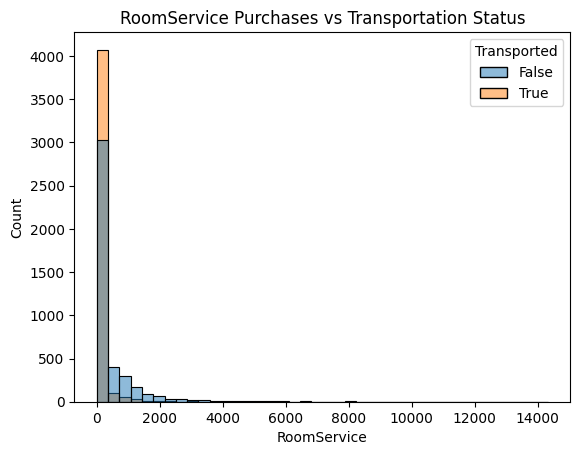

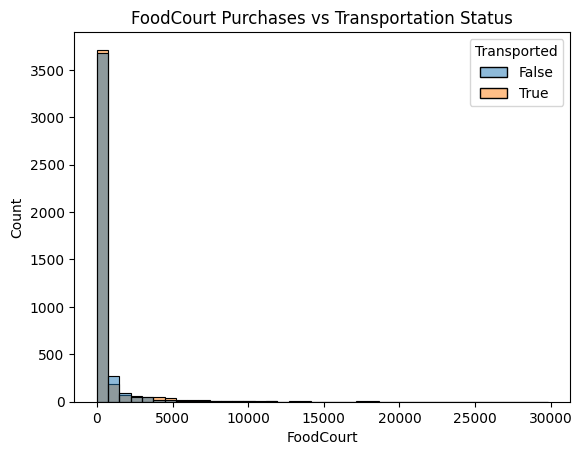

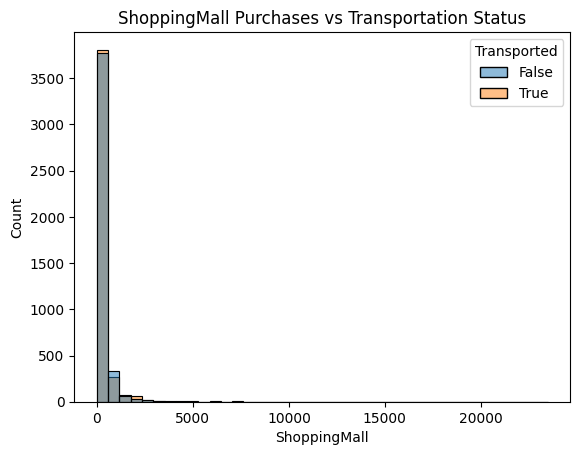

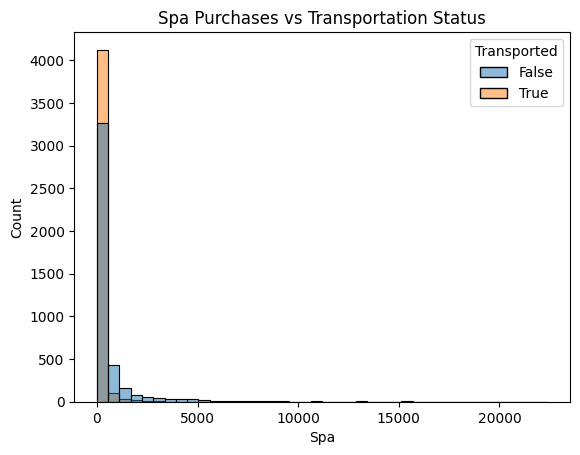

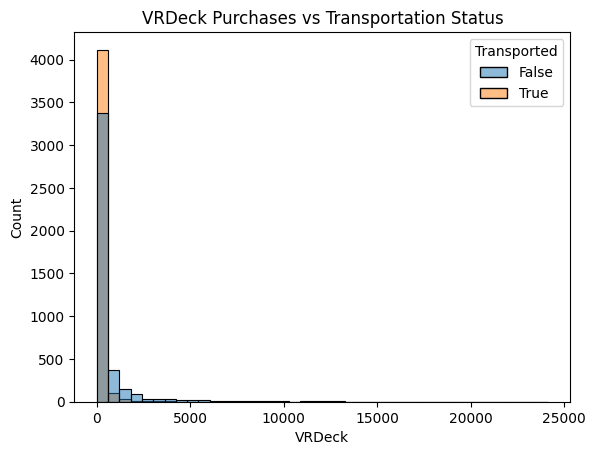

In [290]:
for col in ['RoomService', "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]:
    plt.figure()
    plt.title(col + ' Purchases vs Transportation Status')
    sns.histplot(data=train_df, x=col, hue="Transported", bins = 40)
    plt.show()


- For RoomService, Spa, and VRDeck, passengers who spent less money were more likely to be transported than passengers who spent more money.
- ShoppingMall and FoodCourt had a minimal difference that I would not consider to be significant
- RoomService, Spa, and VRDeck sound like more exclusive, high end features offered on vacations. Not many people purchase these. Thus, transportation could be targetting those who don't buy premium features. (People who spend less money on premium features are more likely to be transported)
- People in CryoSleep also can't purchase any addon packages, let alone premium features (like RoomService, Spa, VRDeck that require you to be awake). This could be why the proportion of Frozen people that are Transported is higher (smaller gap between Frozen and Not) than the proportion of frozen people not transported.

Conclusion: The following features probably have some impact on Transportation status:
- Age
- CryoSleep
- Cabin
- PassengerId
- Destination
- HomePlanet
- RoomService, Spa, VRDeck

Age:
- More passengers whose ages range from 0-<20 were transported
- Less adults, age range 20-40, were transported

Hypothesis: Transportation affected one area of the ship where more children were residing, and fewer adults 20-40 were residing.

CryoSleep:
- Overall, fewer people were frozen.
- However, the proportion of frozen in transported passengers was higher. This could mean that those frozen were Transported at a slightly higher rate than nonfrozen. 

Hypothesis: Transportation affected cabins (where people were frozen) more than common areas.

That led me to ask whether there was a relation between younger passengers and CryoSleep.
- More younger people were in CryoSleep than older people proportionality wise. 
- Because more younger people were transported than older people,and being frozen had a higher chance of transportation, CryoSleep would explain why younger people had higher rates of transportation. 

Cabin:
 - Overall distribution of transportation split by cabins was similar throughout, except for cabin G.
 - The number of non transported passengers was greater in cabin G. (Over 1500 not transported from cabin G, vs 1300 transported from cabin G).
 
 Hypothesis: This could mean that tranportation selected fewer cabin G residents. Maybe it selected cabin G rooms less, or it happened to select spaces with fewer people from cabin G.
 - Since I believe CryoSleep may be positively correlated to Transportation, cabin G should have less CryoSleep. However it actually had more people in CryoSleep (1350 in, 1146 not).

 New Hypothesis: Transportation happened to select common spaces with fewer people from cabin G.

PassengerId:
- For groups of more than 1, if one member of the group was transported, there is a higher chance that other members of the group was also transported. This is supported by the fact that only 237 groups of more than 1 passenger had no one transported.

Hypothesis: Transportation took groups of people at a time who were close to each other. This makes sense, because people traveling together are put in the same group and are often in the same places in the ship.

Destination and HomePlanet:
- Passengers from Europa had more transports
- Passengers to TRAPPIST-1e MAY have fewer transports
- 55 Cancri e has higher transportation rates

Hypothesis: Those from Europa or going to 55 Cancri e had higher transport rates. Transportation could have once again selected people in groups based on proximity. This supports the PassengerId hypothesis (that people in groups move together on the ship). Typically people from one family/group travel to and from the same place, and also explore the ship together. Thus, transportation could be based on physical proximity on the ship.

Room Service, Spa, VRDeck:
- People who don't purchase premium add-ons were transported at higher rates.
- People in CryoSleep can't purchase these add-ons because, 1: they have no use for them, and 2: they can't physically buy them. This could explain why the proportion of frozen people are more likely to be transported.

Hypothesis: Transportation could also be selective based on how much a passenger spends, which may also explain why people who are frozen in CryoSleep are transported at higher rates. Those in similar spending ranges also move around the ship in close proximity, which could explain Destination/HomePlanet and cabin patterns. This may be the biggest reason for transportation, and would definitely be important to include as features.